In [25]:
%pip install faker

840.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached faker-40.1.0-py3-none-any.whl.metadata (16 kB)
Using cached faker-40.1.0-py3-none-any.whl (2.0 MB)


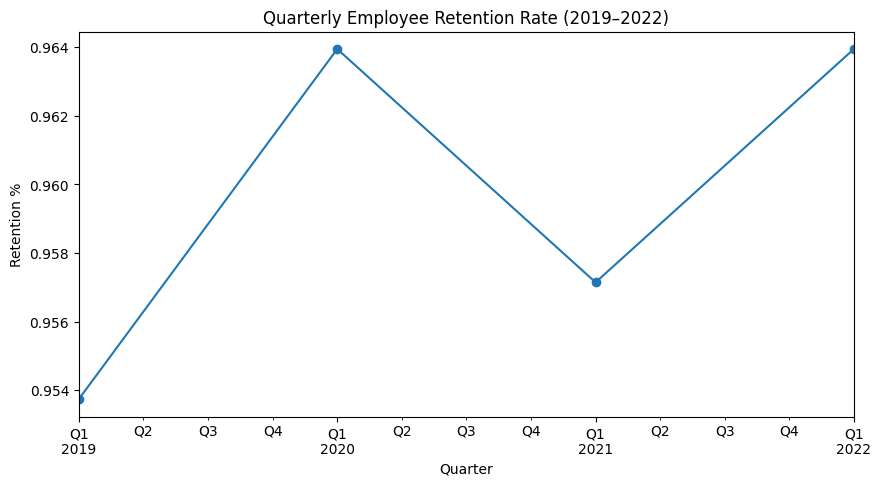

         PseudoName  YearJoined YearResigned ResignDate ResignQuarter
0        Leah Brown        2016         2019 2019-01-01        2019Q1
1       Melody Tran        2012         None        NaT           NaT
2       Seth Miller        2022         2020 2020-01-01        2020Q1
3        Dawn Myers        2014         None        NaT           NaT
4     Mark Mcmillan        2020         None        NaT           NaT
5    Edward Stanley        2015         None        NaT           NaT
6  Mr. Willie Hayes        2021         None        NaT           NaT
7        Sheila Lin        2021         None        NaT           NaT
8    Vincent Campos        2013         None        NaT           NaT
9        Kari Hicks        2015         None        NaT           NaT


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker

# 1. Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 2. Initialize Faker for pseudo names
fake = Faker()

# Generate pseudo names for each employee
df['PseudoName'] = [fake.name() for _ in range(len(df))]

# 3. Create YearJoined
current_year = 2022
df['YearJoined'] = current_year - df['YearsAtCompany']

# 4. Create YearResigned (only for Attrition == Yes)
df['YearResigned'] = np.where(
    df['Attrition'] == 'Yes',
    np.random.choice([2019, 2020, 2021, 2022], size=len(df)),
    None
)

# 5. Final dataset with pseudo names
df_final = df[['PseudoName', 'YearJoined', 'YearResigned']].copy()

# 6. Convert resignation year into quarterly periods
df_final['ResignDate'] = pd.to_datetime(df_final['YearResigned'], format='%Y', errors='coerce')
df_final['ResignQuarter'] = df_final['ResignDate'].dt.to_period('Q')

# 7. Quarterly retention summary
df['Status'] = df['Attrition'].map({'Yes': 'Resigned', 'No': 'Active'})
quarterly_counts = df_final.groupby('ResignQuarter')['PseudoName'].count()
retention_rate = 1 - (quarterly_counts / len(df_final))

# 8. Export cleaned dataset
df_final.to_csv("employee_retention_with_pseudo_names.csv", index=False)

# 9. Visualization
plt.figure(figsize=(10,5))
retention_rate.plot(kind='line', marker='o')
plt.title("Quarterly Employee Retention Rate (2019–2022)")
plt.ylabel("Retention %")
plt.xlabel("Quarter")
plt.show()

# 10. Preview
print(df_final.head(10))
